In [1]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-5-nano")
llm.invoke("hi")

AIMessage(content='Hi there! How can I help today? I can answer questions, explain concepts, help with writing or editing, assist with coding, brainstorm ideas, plan projects, or just chat. Tell me what you’re aiming for or what topic you have in mind, and I’ll jump in.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 515, 'prompt_tokens': 7, 'total_tokens': 522, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 448, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DUaHJZkRMgofCMJGgZ3FrZKV1h8Ae', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d8cad-56c0-7ad0-a675-97619bb719ba-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 515, 'total_tokens': 52

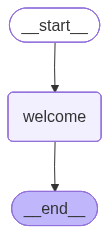

In [11]:
from typing import TypedDict

class base_schema(TypedDict):
    name:str
    message: str

def welcome(dict1:base_schema)->base_schema:
    name=dict1['name']
    msg=dict1['message']
    response=llm.invoke(f"my name is {name} . {msg} .").content
    dict1['message']=f"your message is {msg} and my response is {response}"
    return dict1





from langgraph.graph import StateGraph, START,END

graph=StateGraph(base_schema)
graph.add_node("welcome", welcome)
graph.add_edge(START, "welcome")
graph.add_edge("welcome",END)

first_graph=graph.compile()
from IPython.display import Image, display

Image(first_graph.get_graph().draw_mermaid_png())



In [12]:
first_graph.invoke({"name":"Uthej","message":"How to increase empathy on others ."})

{'name': 'Uthej',
 'message': 'your message is How to increase empathy on others . and my response is Hi Uthej! Nice to meet you. Here are practical ways to encourage or increase empathy in others. Remember, you can’t force someone to feel empathic, but you can model it and create environments that make it more likely.\n\n- Model empathy yourself\n  - Listen actively, without interrupting.\n  - Validate others’ feelings even if you disagree.\n  - Use “I” statements and show understanding: “I hear you’re really frustrated. That sounds tough.”\n\n- Encourage perspective-taking\n  - Ask open-ended questions: “How do you think that would feel from their side?”\n  - Prompt people to consider a situation from another person’s background or circumstances.\n\n- Teach and practice active listening\n  - Give full attention, summarize what you heard, and reflect emotions: “So what you’re feeling is X because of Y?”\n  - Avoid judgment or rushing to solutions before you understand.\n\n- Use emotio

In [30]:
from langchain_openai import ChatOpenAI
from typing import TypedDict
from pydantic import BaseModel, Field
llm=ChatOpenAI(model="gpt-5-nano")


class req_schema(BaseModel):
    topic:str=Field("name of the topic")
    post: str=Field("Linkedin post")
    curated_post:str=Field("Curated Linkedin Post")

def post(dict1:req_schema)->req_schema:
    dict1=dict1.model_dump()
    topic=dict1['topic']
    post=dict1['post']
    curated_post=dict1['curated_post']

    response=llm.invoke(f"please create a linkedin post on topic {topic}").content
    dict1['post']=f"the topic is : {topic}\nthe entire post is '{response}'"
    return dict1



def curate_post(dict1:req_schema)->req_schema:
    dict1=dict1.model_dump()
    topic=dict1['topic']
    post=dict1['post']
    curated_post=dict1['curated_post']

    response=llm.invoke(f"""using the below post , please create 5 questions with 
                        4 choice answers .\nAt the very end mention answers .\nThe post is : '{post}'""").content
    dict1['curated_post']=f"final curated linkedin post is \n'{response}'"
    return dict1


from langgraph.graph import StateGraph, START,END
graph=StateGraph(req_schema)
graph.add_node("post", post)
graph.add_node("curate_post",curate_post)
graph.add_edge(START, "post")
graph.add_edge("post","curate_post")
graph.add_edge("curate_post",END)

first_graph=graph.compile()

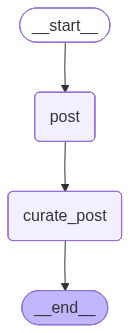

In [15]:
first_graph

In [32]:
dict2={"topic":"python lists",
       "post":"ok ",
       "curate_post":" ok"}

dict2=req_schema(
    topic="python lists",
    post="",
    curated_post=""
)

print(type(dict2))

first_graph.invoke(dict2)


# dict2=req_schema(
#     topic="python lists",
#     post="",
#     curated_post=""
# )
# print(post(dict2))

<class '__main__.req_schema'>


{'topic': 'python lists',
 'post': "the topic is : python lists\nthe entire post is 'Here's a ready-to-post LinkedIn update on Python lists:\n\nPython lists: the Swiss Army knife of Python. Mutable, ordered, and incredibly versatile, they power everything from simple collections to data pipelines. Here are a few quick tips to level up your list game:\n\n- Start with literals for readability: my_list = [1, 2, 3]\n- Grow a list the right way:\n  - append(item) adds a single element\n  - extend(iterable) adds many elements\n  - + concatenates, but be mindful of performance inside loops\n- Copying lists:\n  - Shallow: my_copy = my_list[:] or list(my_list)\n  - Deep copy for nested structures: import copy; deep = copy.deepcopy(my_list)\n- Transform with list comprehensions: squares = [x*x for x in my_list]\n- Sorting:\n  - sorted(my_list) returns a new sorted list\n  - my_list.sort() sorts in place\n- Be mindful of mutability and aliasing when passing lists into functions\n- Performance tip